In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
#Load dataset
import pandas as pd
df = pd.read_csv("Train.csv")

In [5]:
print(df.columns)

Index(['POSTED_BY', 'UNDER_CONSTRUCTION', 'RERA', 'BHK_NO.', 'BHK_OR_RK',
       'SQUARE_FT', 'READY_TO_MOVE', 'RESALE', 'ADDRESS', 'LONGITUDE',
       'LATITUDE', 'TARGET(PRICE_IN_LACS)'],
      dtype='str')


In [6]:
print(df.columns.tolist())

['POSTED_BY', 'UNDER_CONSTRUCTION', 'RERA', 'BHK_NO.', 'BHK_OR_RK', 'SQUARE_FT', 'READY_TO_MOVE', 'RESALE', 'ADDRESS', 'LONGITUDE', 'LATITUDE', 'TARGET(PRICE_IN_LACS)']


In [7]:
#features and target
X = df.drop("TARGET(PRICE_IN_LACS)", axis=1)
y = df["TARGET(PRICE_IN_LACS)"]

print(X.shape)
print(y.shape)

(29451, 11)
(29451,)


In [8]:
#Encoding
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(29451, 6909)


In [9]:
print(X.shape)

(29451, 6909)


In [10]:
X = df.drop(["TARGET(PRICE_IN_LACS)", "ADDRESS"], axis=1)
y = df["TARGET(PRICE_IN_LACS)"]

X = pd.get_dummies(X, drop_first=True)

In [11]:
#Train-test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [18]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [19]:
import pickle

with open("house_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


In [13]:
#Prediction and Evaluation
y_pred = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE =", mean_absolute_error(y_test, y_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score =", r2_score(y_test, y_pred))

MAE = 34.958728209147274
RMSE = 374.02880775078603
R2 Score = 0.7432446468175951


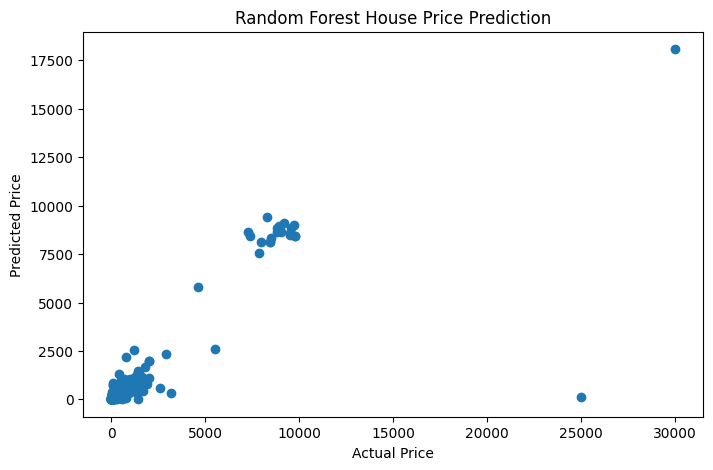

In [14]:
#Graph Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest House Price Prediction")
plt.show()

In [15]:
print("Actual Price =", y_test.iloc[0])
print("Predicted Price =", y_pred[0])

Actual Price = 34.9
Predicted Price = 63.57700000000002


In [20]:
import pickle

# Save model
pickle.dump(model, open("house_price_model.pkl", "wb"))

# Save column names after encoding
pickle.dump(X.columns, open("model_columns.pkl", "wb"))

print("Model and columns saved successfully!")

Model and columns saved successfully!


In [21]:
X.columns

Index(['UNDER_CONSTRUCTION', 'RERA', 'BHK_NO.', 'SQUARE_FT', 'READY_TO_MOVE',
       'RESALE', 'LONGITUDE', 'LATITUDE', 'POSTED_BY_Dealer',
       'POSTED_BY_Owner', 'BHK_OR_RK_RK'],
      dtype='str')